In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [3]:
donations  = pd.read_csv('data/donations.csv')
web        = pd.read_csv('data/web_analytics.csv')
marketing  = pd.read_csv('data/marketing_performance.csv')
impact     = pd.read_csv('data/impact_metrics.csv')

donations['donation_date'] = pd.to_datetime(donations['donation_date'])
web['date']                = pd.to_datetime(web['date'])
marketing['date']          = pd.to_datetime(marketing['date'])

print('✅ All datasets loaded')
print(f'   donations      : {donations.shape}')
print(f'   web_analytics  : {web.shape}')
print(f'   marketing      : {marketing.shape}')
print(f'   impact_metrics : {impact.shape}')

✅ All datasets loaded
   donations      : (150, 8)
   web_analytics  : (120, 4)
   marketing      : (270, 5)
   impact_metrics : (6, 3)


In [5]:
print('=== DONATIONS ===')
display(donations.head())
print('\n=== WEB ANALYTICS ===')
display(web.head())
print('\n=== MARKETING ===')
display(marketing.head())
print('\n=== IMPACT METRICS ===')
display(impact.head())

=== DONATIONS ===


,donation_id,donor_id,donation_date,donation_amount,currency,platform,campaign,donation_type
0,T0001,D010,2024-02-19,100,USD,Givebutter,Emergency Surgery Fund,One-Time
1,T0002,D047,2024-01-25,75,USD,PayPal,Emergency Surgery Fund,Recurring
2,T0003,D041,2024-09-16,1000,USD,Stripe,Patient Care Fund,One-Time
3,T0004,D049,2024-08-13,250,USD,PayPal,Patient Care Fund,One-Time
4,T0005,D015,2024-06-24,500,USD,Stripe,General Support,One-Time



=== WEB ANALYTICS ===


,date,sessions,source,donations_completed
0,2024-05-01,1048,Direct,1
1,2024-05-02,492,Direct,8
2,2024-05-03,1092,Organic,14
3,2024-05-04,1019,Direct,13
4,2024-05-05,1118,Referral,3



=== MARKETING ===


,date,channel,impressions,clicks,spend_usd
0,2024-06-01,Google Ads,4556,264,170.49
1,2024-06-01,Meta Ads,3062,176,227.95
2,2024-06-01,Email,3720,158,121.43
3,2024-06-02,Google Ads,2945,265,288.92
4,2024-06-02,Meta Ads,1779,265,89.89



=== IMPACT METRICS ===


,month,patients_served,avg_cost_savings_per_patient_usd
0,2024-01,62,10311
1,2024-02,74,11801
2,2024-03,24,10351
3,2024-04,48,13264
4,2024-05,41,12586


In [7]:
print('Missing values per dataset:')
for name, df in [('donations', donations), ('web', web), ('marketing', marketing), ('impact', impact)]:
    missing = df.isnull().sum().sum()
    print(f'  {name}: {missing} missing values')

Missing values per dataset:
  donations: 0 missing values
  web: 0 missing values
  marketing: 0 missing values
  impact: 0 missing values


In [9]:
total       = donations['donation_amount'].sum()
avg         = donations['donation_amount'].mean()
n_donors    = donations['donor_id'].nunique()
n_donations = len(donations)

print('📌 Key Donation Metrics')
print(f'   Total Funds Raised : ${total:,.0f}')
print(f'   Avg Donation       : ${avg:,.2f}')
print(f'   Unique Donors      : {n_donors}')
print(f'   Total Donations    : {n_donations}')

📌 Key Donation Metrics
   Total Funds Raised : $35,900
   Avg Donation       : $239.33
   Unique Donors      : 50
   Total Donations    : 150


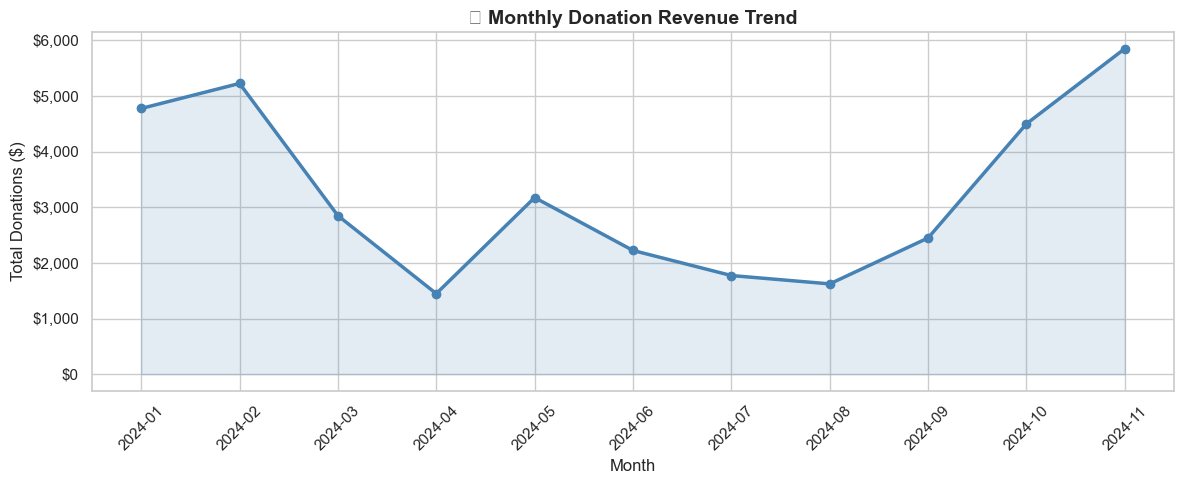

In [11]:
import os
os.makedirs('screenshots', exist_ok=True)

donations['month'] = donations['donation_date'].dt.to_period('M')
monthly = donations.groupby('month')['donation_amount'].sum().reset_index()
monthly['month_str'] = monthly['month'].astype(str)

fig, ax = plt.subplots()
ax.plot(monthly['month_str'], monthly['donation_amount'], marker='o', color='steelblue', linewidth=2.5)
ax.fill_between(monthly['month_str'], monthly['donation_amount'], alpha=0.15, color='steelblue')
ax.set_title('📈 Monthly Donation Revenue Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Donations ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('screenshots/monthly_trend.png', dpi=150)
plt.show()

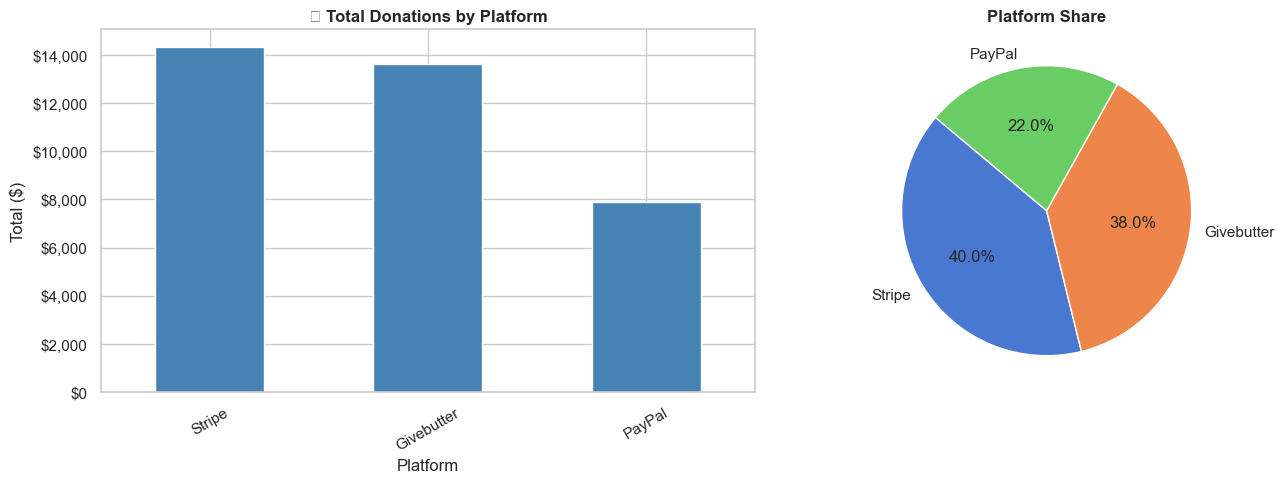

In [13]:
by_platform = donations.groupby('platform')['donation_amount'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

by_platform.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('💳 Total Donations by Platform', fontweight='bold')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Total ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)

by_platform.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Platform Share', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('screenshots/platform_breakdown.png', dpi=150)
plt.show()

In [15]:
by_campaign = donations.groupby('campaign').agg(
    total_raised=('donation_amount', 'sum'),
    num_donations=('donation_id', 'count'),
    avg_donation=('donation_amount', 'mean')
).sort_values('total_raised', ascending=False)

print('🎯 Campaign Performance:')
display(by_campaign.style.format({'total_raised': '${:,.0f}', 'avg_donation': '${:,.2f}'}))

🎯 Campaign Performance:


,total_raised,num_donations,avg_donation
campaign,,,
General Support,"$12,625",58,$217.67
Emergency Surgery Fund,"$12,425",42,$295.83
Patient Care Fund,"$10,850",50,$217.00


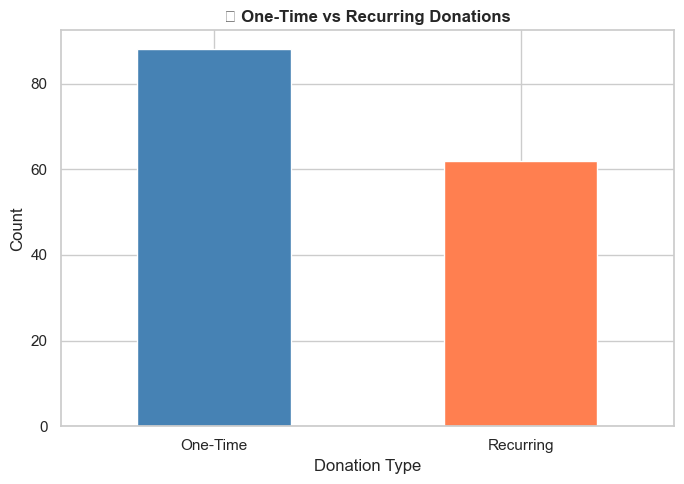

In [17]:
dtype_counts = donations['donation_type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
dtype_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='white')
ax.set_title('🔄 One-Time vs Recurring Donations', fontweight='bold')
ax.set_xlabel('Donation Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('screenshots/donation_types.png', dpi=150)
plt.show()

In [19]:
mkt = marketing.groupby('channel').agg(
    total_spend=('spend_usd', 'sum'),
    total_impressions=('impressions', 'sum'),
    total_clicks=('clicks', 'sum')
).reset_index()

mkt['ctr'] = (mkt['total_clicks'] / mkt['total_impressions'] * 100).round(2)
mkt['cost_per_click'] = (mkt['total_spend'] / mkt['total_clicks']).round(2)
mkt_sorted = mkt.sort_values('total_spend', ascending=False)

print('📣 Marketing Channel Performance:')
display(mkt_sorted.style.format({
    'total_spend': '${:,.0f}',
    'ctr': '{:.2f}%',
    'cost_per_click': '${:.2f}'
}))


📣 Marketing Channel Performance:


,channel,total_spend,total_impressions,total_clicks,ctr,cost_per_click
2,Meta Ads,"$15,078",245097,15051,6.14%,$1.00
1,Google Ads,"$14,314",265444,14062,5.30%,$1.02
0,Email,"$14,183",236156,14046,5.95%,$1.01


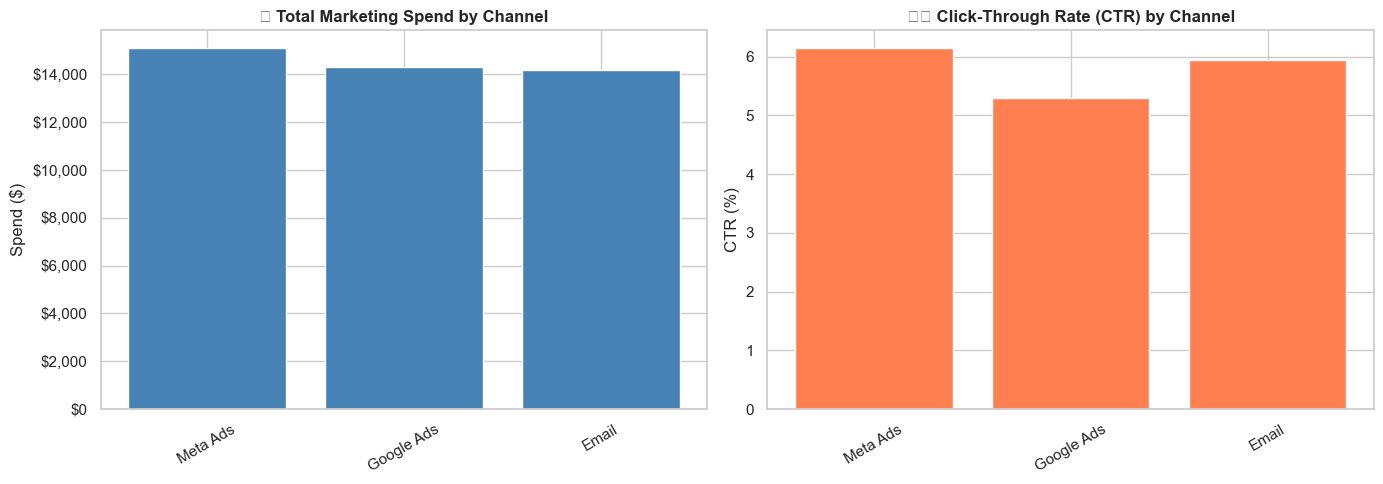

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(mkt_sorted['channel'], mkt_sorted['total_spend'], color='steelblue', edgecolor='white')
axes[0].set_title('💸 Total Marketing Spend by Channel', fontweight='bold')
axes[0].set_ylabel('Spend ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(mkt_sorted['channel'], mkt_sorted['ctr'], color='coral', edgecolor='white')
axes[1].set_title('🖱️ Click-Through Rate (CTR) by Channel', fontweight='bold')
axes[1].set_ylabel('CTR (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('screenshots/marketing_channels.png', dpi=150)
plt.show()

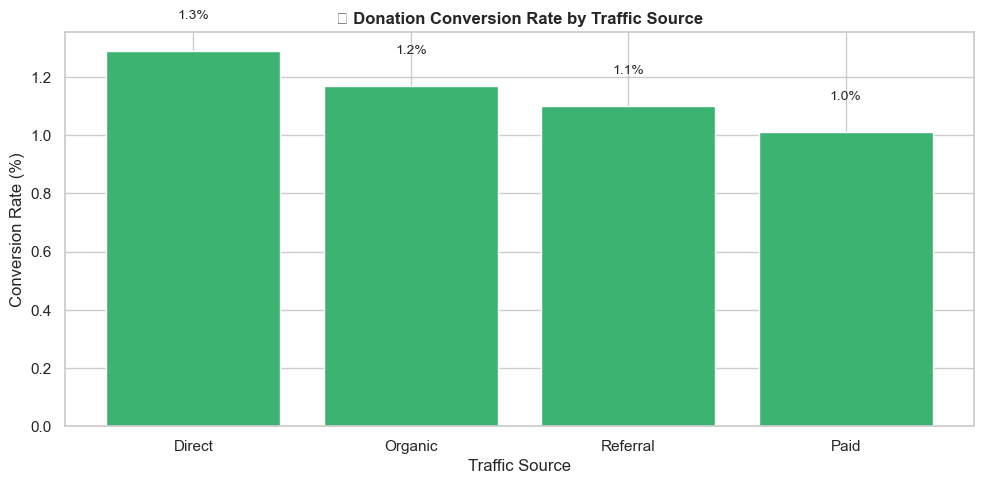

In [23]:
by_source = web.groupby('source').agg(
    total_sessions=('sessions', 'sum'),
    total_conversions=('donations_completed', 'sum')
).reset_index()
by_source['conversion_rate'] = (by_source['total_conversions'] / by_source['total_sessions'] * 100).round(2)
by_source = by_source.sort_values('conversion_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(by_source['source'], by_source['conversion_rate'], color='mediumseagreen', edgecolor='white')
ax.set_title('🎯 Donation Conversion Rate by Traffic Source', fontweight='bold')
ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('Traffic Source')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('screenshots/conversion_by_source.png', dpi=150)
plt.show()

In [25]:
impact['total_savings'] = impact['patients_served'] * impact['avg_cost_savings_per_patient_usd']

top_platform = by_platform.idxmax()
top_source   = by_source.loc[by_source['conversion_rate'].idxmax(), 'source']
top_channel  = mkt_sorted.loc[mkt_sorted['ctr'].idxmax(), 'channel']

print('=' * 55)
print('         📋 KEY INSIGHTS SUMMARY')
print('=' * 55)
print(f'  💰 Total Funds Raised       : ${total:,.0f}')
print(f'  👥 Unique Donors            : {n_donors}')
print(f'  📊 Avg Donation Amount      : ${avg:,.2f}')
print(f'  🏆 Top Donation Platform    : {top_platform}')
print(f'  🌐 Best Converting Source   : {top_source}')
print(f'  📣 Highest CTR Channel      : {top_channel}')
print(f'  🏥 Total Patients Served    : {impact["patients_served"].sum():,}')
print(f'  💚 Total Cost Savings       : ${impact["total_savings"].sum():,.0f}')
print('=' * 55)

         📋 KEY INSIGHTS SUMMARY
  💰 Total Funds Raised       : $35,900
  👥 Unique Donors            : 50
  📊 Avg Donation Amount      : $239.33
  🏆 Top Donation Platform    : Stripe
  🌐 Best Converting Source   : Direct
  📣 Highest CTR Channel      : Meta Ads
  🏥 Total Patients Served    : 270
  💚 Total Cost Savings       : $3,126,681
